In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

data_train = pd.read_csv ( './data/synth_train.txt' , sep = r"\s+" )

In [2]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       100 non-null    int64  
 1   x1      100 non-null    float64
 2   x2      100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [3]:
data_train.head(6)

,y,x1,x2
0,2,-0.722211,2.004471
1,2,-0.924679,0.483669
2,2,-0.766023,0.794329
3,2,-0.073289,0.969929
4,1,-1.392912,0.999697
5,2,-0.202233,1.350332


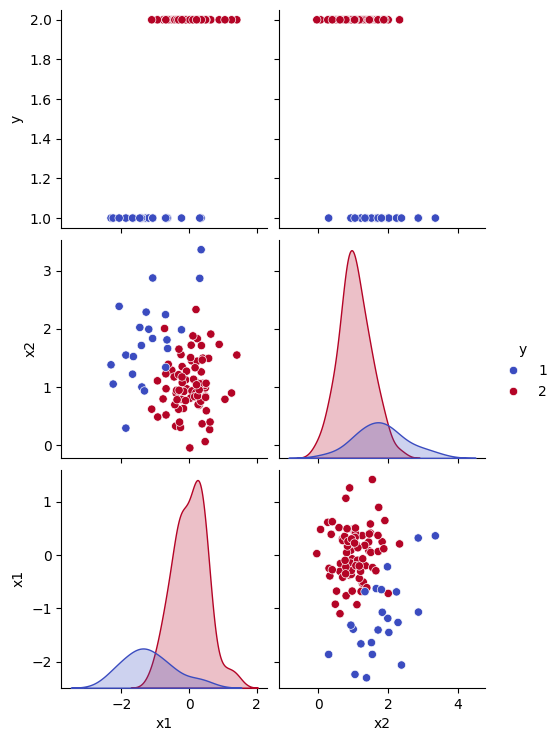

In [4]:
import seaborn as sns

sns.pairplot(data_train, hue="y", 
             x_vars=["x1", "x2"],
             y_vars=["y","x2","x1"],
             palette="coolwarm")



In [ ]:
y_train=data_train["y"].values
X_train=data_train.iloc[:, -2:].values

knn = KNeighborsClassifier(n_neighbors=15)

knn.fit(X_train, y_train)
data = {'x1': [0, -2], 
        'x2': [0, 2]
        }
Q2_X= pd.DataFrame(data)
print()
Q2_X["pred"]=knn.predict(Q2_X)

print(Q2_X)


   x1  x2  pred
0   0   0     2
1  -2   2     1


/home/snds/.local/lib/python3.13/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [6]:
y_pred=knn.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Error: {1-accuracy:.2f}")

Error: 0.08


In [7]:
Ks = [10, 5, 1]
for k in Ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_train)
    accuracy = accuracy_score(y_train, y_pred)
    print(f"K= {k} Error: {1-accuracy:.4f}")

K= 10 Error: 0.0600
K= 5 Error: 0.0500
K= 1 Error: 0.0000


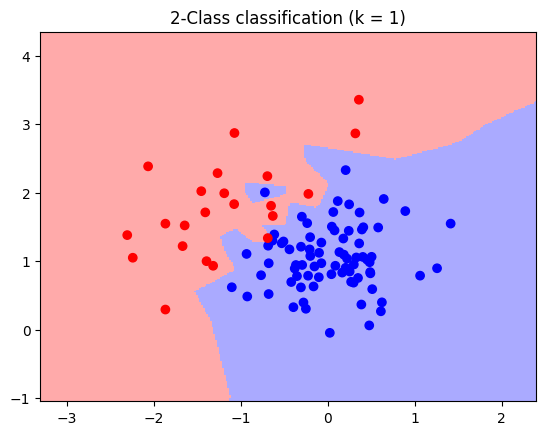

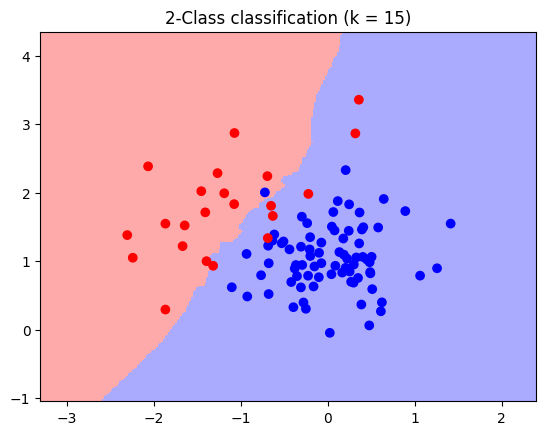

In [15]:
Ks=[1,15]
h = .02  # step size in the mesh

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
clfs=[]
for i,k in enumerate(Ks):
    
   
    clfs.insert(i,KNeighborsClassifier(n_neighbors=k))
    clfs[i].fit(X_train, y_train)

    
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    Z = clfs[i].predict(np.c_[xx.ravel(), yy.ravel()])

   
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("2-Class classification (k = %i)"
            % (k))

    plt.show()

In [24]:
data_test = pd.read_csv('./data/synth_test.txt', sep=r"\s+")
y_test = data_test["y"].values
X_test = data_test.iloc[:, -2:].values
y_pred = []

for k, clf in zip(Ks, clfs):
    print("-"*50)
    
    print(f"Training Set Accuracy: k={k} ")
    accuracy = clf.score(X_train, y_train)
    error_rate = 1 - accuracy
    print(f"Empirical Error Rate: {(error_rate*100):.2f}%")
    
    print("-"*50)
    
    print(f"Test Set Accuracy: k={k}")
    accuracy = clf.score(X_test, y_test)
    error_rate = 1 - accuracy
    print(f"Empirical Error Rate: {(error_rate*100):.2f}%")
    
    print("-"*50)

--------------------------------------------------
Training Set Accuracy: k=1 
Empirical Error Rate: 0.00%
--------------------------------------------------
Test Set Accuracy: k=1
Empirical Error Rate: 6.50%
--------------------------------------------------
--------------------------------------------------
Training Set Accuracy: k=15 
Empirical Error Rate: 8.00%
--------------------------------------------------
Test Set Accuracy: k=15
Empirical Error Rate: 7.50%
--------------------------------------------------


In [41]:
from sklearn.metrics import confusion_matrix

y_pred=clfs[1].predict(X_test)
cm = confusion_matrix(y_test, y_pred,labels=[2, 1]) #2 is negative and 1 is positive 


TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

print(f"Confusion Matrix:\n{cm}")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

 
TNR = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"TP = {TP}, FN = {FN}, FP = {FP}, TN = {TN}")
print(f"TPR (Recall/Sensitivity) = {TPR:.4f}")
print(f"TNR (Specificity) = {TNR:.4f}")


Confusion Matrix:
[[138   0]
 [ 15  47]]
True Positives (TP): 47
True Negatives (TN): 138
False Positives (FP): 0
False Negatives (FN): 15
TP = 47, FN = 15, FP = 0, TN = 138
TPR (Recall/Sensitivity) = 0.7581
TNR (Specificity) = 1.0000


In [43]:
from sklearn.neighbors import KNeighborsClassifier

def prob_knn(X_train, y_train, X_test, k=15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    neighbors_indices = knn.kneighbors(X_test, return_distance=False)
    prob = []
    for idx_arr in neighbors_indices:
       
        proportion_1 = np.mean(y_train[idx_arr] == 1)
        prob.append(proportion_1)
    return np.array(prob)


p_hat = prob_knn(X_train, y_train, X_test, k=15)


threshold = 0.25
y_pred = np.where(p_hat > threshold, 1, 2)

cm = confusion_matrix(y_test, y_pred,labels=[2, 1]) #2 is negative and 1 is positive 


TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]


TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

 
TNR = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Confusion Matrix:\n{cm}")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

print(f"TPR (Recall/Sensitivity) = {TPR:.4f}")
print(f"TNR (Specificity) = {TNR:.4f}")


total_cost = FN * 3 + FP * 1
print(f"Total Cost = {FN}×3 + {FP}×1 = {total_cost}")

Confusion Matrix:
[[134   4]
 [  8  54]]
True Positives (TP): 54
True Negatives (TN): 134
False Positives (FP): 4
False Negatives (FN): 8
TPR (Recall/Sensitivity) = 0.8710
TNR (Specificity) = 0.9710
Total Cost = 8×3 + 4×1 = 28


by making false negatives more costly we lost some specificity but we gained sensivity! 